In [5]:
%matplotlib inline
import cv2
import os
import numpy as np
import keras
import matplotlib.pyplot as plt
# import download
from random import shuffle
from tensorflow.keras.applications import VGG16
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Activation
import sys
import h5py

In [9]:
# from google.colab import drive
# drive.mount('/content/gdrive')a

In [6]:
def print_progress(count, max_count):
    # Percentage completion.
    pct_complete = count / max_count

    # Status-message. Note the \r which means the line should
    # overwrite itself.
    msg = "\r- Progress: {0:.1%}".format(pct_complete)

    # Print it.
    sys.stdout.write(msg)
    sys.stdout.flush()

In [7]:
in_dir = "data"
# Frame size
img_size = 224

img_size_touple = (img_size, img_size)

# Number of channels (RGB)
num_channels = 3

# Flat frame size
img_size_flat = img_size * img_size * num_channels

# Number of classes for classification (Violence-No Violence)
num_classes = 2

# Number of files to train
_num_files_train = 1

# Number of frames per video
_images_per_file = 20

# Number of frames per training set
_num_images_train = _num_files_train * _images_per_file

# Video extension
video_exts = ".avi"

In [8]:
def get_frames(current_dir, file_name):

    in_file = os.path.join(current_dir, file_name)
    images = []
    vidcap = cv2.VideoCapture(in_file)
    success,image = vidcap.read()
    count = 0

    while count<_images_per_file:
        RGB_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        res = cv2.resize(RGB_img, dsize=(img_size, img_size),
                                 interpolation=cv2.INTER_CUBIC)

        images.append(res)
        success,image = vidcap.read()
        count += 1
    resul = np.array(images)
    resul = (resul / 255.).astype(np.float16)
    return resul

def label_video_names(in_dir):
    # list containing video names
    names = []
    # list containin video labels [1, 0] if it has violence and [0, 1] if not
    labels = []

    for current_dir, dir_names,file_names in os.walk(in_dir):
        for file_name in file_names:
            if file_name[0:2] == 'fi':
                labels.append([1,0])
                names.append(file_name)
            elif file_name[0:2] == 'no':
                labels.append([0,1])
                names.append(file_name)

    c = list(zip(names,labels))
    # Suffle the data (names and labels)
    shuffle(c)
    names, labels = zip(*c)

    return names, labels

In [9]:
# First get the names and labels of the whole videos
names, labels = label_video_names(in_dir)

In [14]:
len(names)

1000

In [10]:
from tensorflow.keras.applications import VGG16

# Define the path to the pre-trained weights file
weights_path = 'vgg16_weights_tf_dim_ordering_tf_kernels.h5'

# Create the VGG16 model with the specified weights file
image_model = VGG16(weights=weights_path, include_top=True)

image_model.summary()

# We will use the output of the layer prior to the final
# classification-layer which is named fc2. This is a fully-connected (or dense) layer.
transfer_layer = image_model.get_layer('fc2')

image_model_transfer = Model(inputs=image_model.input,
                             outputs=transfer_layer.output)

transfer_values_size = K.int_shape(transfer_layer.output)[1]


print("The input of the VGG16 net have dimensions:",K.int_shape(image_model.input)[1:3])

print("The output of the selecter layer of VGG16 net have dimensions: ", transfer_values_size)

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

The input of the VGG16 net have dimensions: (224, 224)
The output of the selecter layer of VGG16 net have dimensions:  4096


In [14]:
def get_transfer_values(current_dir, file_name):
    # Pre-allocate input-batch-array for images.
    shape = (_images_per_file,) + img_size_touple + (3,)

    image_batch = np.zeros(shape=shape, dtype=np.float16)

    image_batch = get_frames(current_dir, file_name)

    # Pre-allocate output-array for transfer-values.
    # Note that we use 16-bit floating-points to save memory.
    shape = (_images_per_file, transfer_values_size)
    transfer_values = np.zeros(shape=shape, dtype=np.float16)

    transfer_values = image_model_transfer.predict(image_batch)

    return transfer_values



def proces_transfer(vid_names, in_dir, labels):

    count = 0
    tam = len(vid_names)

    # Pre-allocate input-batch-array for images.
    shape = (_images_per_file,) + img_size_touple + (3,)

    while count<tam:
        video_name = vid_names[count]
        image_batch = np.zeros(shape=shape, dtype=np.float16)
        image_batch = get_frames(in_dir, video_name)
         # Note that we use 16-bit floating-points to save memory.
        shape = (_images_per_file, transfer_values_size)
        transfer_values = np.zeros(shape=shape, dtype=np.float16)

        transfer_values = \
            image_model_transfer.predict(image_batch)

        labels1 = labels[count]
        aux = np.ones([20,2])
        labelss = labels1*aux

        yield transfer_values, labelss

        count+=1


In [149]:
def make_files(n_files):
    gen = proces_transfer(names_training, in_dir, labels_training)
    numer = 1
    # Read the first chunk to get the column dtypes
    chunk = next(gen)

    row_count = chunk[0].shape[0]
    row_count2 = chunk[1].shape[0]

    with h5py.File('prueba.h5', 'w') as f:
        # Initialize a resizable dataset to hold the output
        maxshape = (None,) + chunk[0].shape[1:]
        maxshape2 = (None,) + chunk[1].shape[1:]

        dset = f.create_dataset('data', shape=chunk[0].shape, maxshape=maxshape,
                                chunks=chunk[0].shape, dtype=chunk[0].dtype)

        dset2 = f.create_dataset('labels', shape=chunk[1].shape, maxshape=maxshape2,
                                 chunks=chunk[1].shape, dtype=chunk[1].dtype)

         # Write the first chunk of rows
        dset[:] = chunk[0]
        dset2[:] = chunk[1]

        for chunk in gen:
            if numer == n_files:
                break
            # Resize the dataset to accommodate the next chunk of rows
            dset.resize(row_count + chunk[0].shape[0], axis=0)
            dset2.resize(row_count2 + chunk[1].shape[0], axis=0)

            # Write the next chunk
            dset[row_count:] = chunk[0]
            dset2[row_count:] = chunk[1]

            # Increment the row count
            row_count += chunk[0].shape[0]
            row_count2 += chunk[1].shape[0]

            print_progress(numer, n_files)

            numer += 1
            
def make_files_test(n_files):

    gen = proces_transfer(names_test, in_dir, labels_test)
    numer = 1
    # Read the first chunk to get the column dtypes
    chunk = next(gen)

    row_count = chunk[0].shape[0]
    row_count2 = chunk[1].shape[0]

    with h5py.File('pruebavalidation.h5', 'w') as f:
        # Initialize a resizable dataset to hold the output
        maxshape = (None,) + chunk[0].shape[1:]
        maxshape2 = (None,) + chunk[1].shape[1:]

        dset = f.create_dataset('data', shape=chunk[0].shape, maxshape=maxshape,
                                chunks=chunk[0].shape, dtype=chunk[0].dtype)

        dset2 = f.create_dataset('labels', shape=chunk[1].shape, maxshape=maxshape2,
                                 chunks=chunk[1].shape, dtype=chunk[1].dtype)

         # Write the first chunk of rows
        dset[:] = chunk[0]
        dset2[:] = chunk[1]

        for chunk in gen:
            if numer == n_files:
                break

            # Resize the dataset to accommodate the next chunk of rows
            dset.resize(row_count + chunk[0].shape[0], axis=0)
            dset2.resize(row_count2 + chunk[1].shape[0], axis=0)

            # Write the next chunk
            dset[row_count:] = chunk[0]
            dset2[row_count:] = chunk[1]

            # Increment the row count
            row_count += chunk[0].shape[0]
            row_count2 += chunk[1].shape[0]

            print_progress(numer, n_files)

            numer += 1


In [150]:
training_set = int(len(names)*0.8)
test_set = int(len(names)*0.2)

In [145]:
names_training = names[0:training_set]
names_test = names[training_set:]

labels_training = labels[0:training_set]
labels_test = labels[training_set:]

In [ ]:

make_files(training_set)
make_files_test(test_set)

from IPython.display import clear_output
clear_output()

In [43]:
def process_alldata_training():
    joint_transfer=[]
    frames_num=20
    count = 0
    with h5py.File('prueba.h5', 'r') as f:
        X_batch = f['data'][:]
        y_batch = f['labels'][:]

    for i in range(int(len(X_batch)/frames_num)):
        inc = count+frames_num
        joint_transfer.append([X_batch[count:inc],y_batch[count]])
        count =inc

    data =[]
    target=[]

    for i in joint_transfer:
        data.append(i[0])
        target.append(np.array(i[1]))

    return data, target


def process_alldata_test():
    joint_transfer=[]
    frames_num=20
    count = 0
    with h5py.File('pruebavalidation.h5', 'r') as f:
        X_batch = f['data'][:]
        y_batch = f['labels'][:]

    for i in range(int(len(X_batch)/frames_num)):
        inc = count+frames_num
        joint_transfer.append([X_batch[count:inc],y_batch[count]])
        count =inc

    data =[]
    target=[]

    for i in joint_transfer:
        data.append(i[0])
        target.append(np.array(i[1]))

    return data, target

In [44]:
data, target = process_alldata_training()
data_test, target_test = process_alldata_test()

In [45]:
np.array(data).shape

(800, 20, 4096)

In [46]:
np.array(target_test).shape

(200, 2)

In [47]:
chunk_size = 4096
n_chunks = 20
rnn_size = 512

model = Sequential()
model.add(LSTM(rnn_size, input_shape=(n_chunks, chunk_size)))
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dense(50))
model.add(Activation('sigmoid'))
model.add(Dense(2))
model.add(Activation('softmax'))    
model.compile(loss='mean_squared_error', optimizer='adam',metrics=['accuracy'])
epoch = 30
batchS = 500

history = model.fit(np.array(data[0:720]), np.array(target[0:720]), epochs=epoch,
                    validation_data=(np.array(data[720:]), np.array(target[720:])),
                    batch_size=batchS, verbose=2)

Epoch 1/30
2/2 - 8s - 4s/step - accuracy: 0.5125 - loss: 0.3006 - val_accuracy: 0.4250 - val_loss: 0.3408
Epoch 2/30
2/2 - 3s - 2s/step - accuracy: 0.5069 - loss: 0.2950 - val_accuracy: 0.5750 - val_loss: 0.2464
Epoch 3/30
2/2 - 3s - 2s/step - accuracy: 0.4931 - loss: 0.2663 - val_accuracy: 0.4250 - val_loss: 0.2787
Epoch 4/30
2/2 - 3s - 2s/step - accuracy: 0.5181 - loss: 0.2580 - val_accuracy: 0.4250 - val_loss: 0.2713
Epoch 5/30
2/2 - 3s - 2s/step - accuracy: 0.5181 - loss: 0.2506 - val_accuracy: 0.5750 - val_loss: 0.2406
Epoch 6/30
2/2 - 3s - 1s/step - accuracy: 0.4819 - loss: 0.2477 - val_accuracy: 0.5750 - val_loss: 0.2368
Epoch 7/30
2/2 - 3s - 2s/step - accuracy: 0.4819 - loss: 0.2458 - val_accuracy: 0.6750 - val_loss: 0.2408
Epoch 8/30
2/2 - 3s - 1s/step - accuracy: 0.6403 - loss: 0.2392 - val_accuracy: 0.4250 - val_loss: 0.2412
Epoch 9/30
2/2 - 3s - 2s/step - accuracy: 0.5444 - loss: 0.2322 - val_accuracy: 0.9125 - val_loss: 0.2250
Epoch 10/30
2/2 - 3s - 2s/step - accuracy: 0.8

In [48]:
result = model.evaluate(np.array(data_test), np.array(target_test))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8772 - loss: 0.1021


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


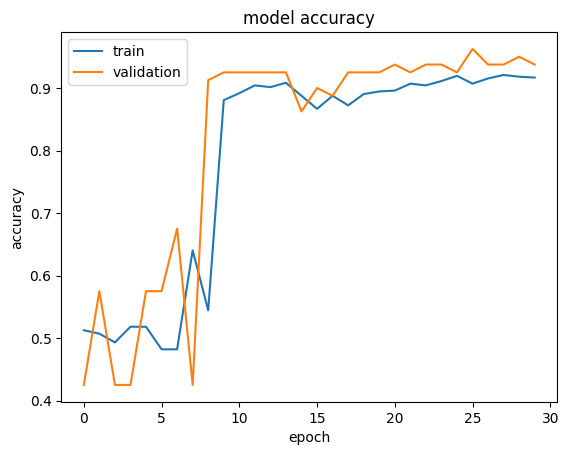

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


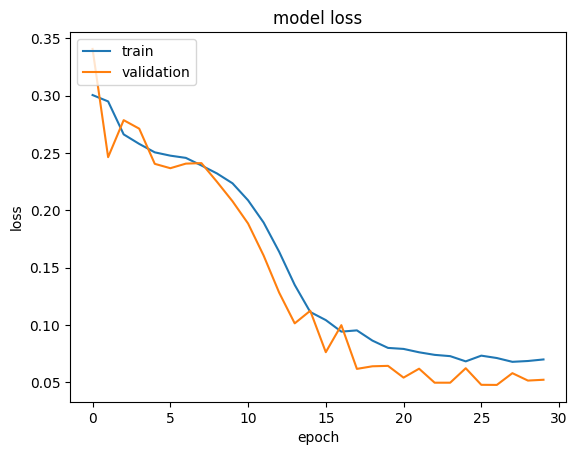

In [49]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.savefig('destination_path.eps', format='eps', dpi=1000)
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.savefig('destination_path1.eps', format='eps', dpi=1000)
plt.show()

In [50]:
result1 = model.predict(np.array(data))

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step


In [51]:
result1.shape

(800, 2)

In [52]:
#Thresholding
result = np.copy(result1)
result = result.reshape(1600)

new_result=[]
for i in range(1600):
  if result[i]>0.5:
    new_result.append(1)
  else:
    new_result.append(0)

new_result=np.array(new_result)
new_result=new_result.reshape(800,2)

result = new_result

In [53]:
vid_number = 184
frames = get_frames(in_dir, names[vid_number])
visible_frame = (frames*255).astype('uint8')

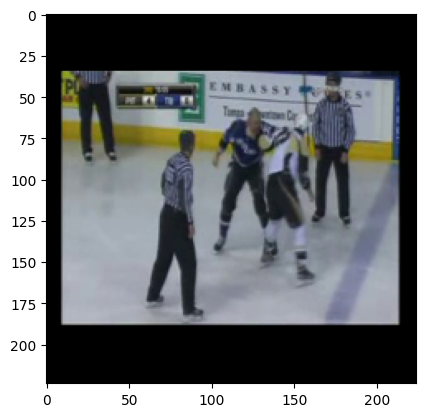

In [54]:
plt.imshow(visible_frame[9])

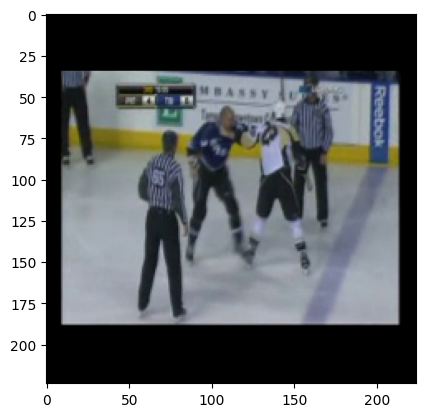

In [55]:
plt.imshow(visible_frame[18])

In [56]:
print(result1[vid_number])
print(result[vid_number])
print(names[vid_number])

[0.9786305  0.02136949]
[1 0]
fi474_xvid.avi


In [445]:
# Import joblib directly
import joblib

In [446]:
# Then you can use joblib to dump your model
joblib.dump(model, 'my_dl_model')

['my_dl_model']

In [447]:
my_model=joblib.load('my_dl_model')

In [448]:
custom_dir = "data_custom"

In [504]:
names_custom , labels_custom = label_video_names(custom_dir)

In [505]:
def make_files_custom(n_files):
    gen = proces_transfer(names_custom, custom_dir, labels_custom)
    numer = 1
    # Read the first chunk to get the column dtypes
    chunk = next(gen)

    row_count = chunk[0].shape[0]
    row_count2 = chunk[1].shape[0]

    with h5py.File('prueba_custom.h5', 'w') as f:
        # Initialize a resizable dataset to hold the output
        maxshape = (None,) + chunk[0].shape[1:]
        maxshape2 = (None,) + chunk[1].shape[1:]

        dset = f.create_dataset('data', shape=chunk[0].shape, maxshape=maxshape,
                                chunks=chunk[0].shape, dtype=chunk[0].dtype)

        dset2 = f.create_dataset('labels', shape=chunk[1].shape, maxshape=maxshape2,
                                 chunks=chunk[1].shape, dtype=chunk[1].dtype)

         # Write the first chunk of rows
        dset[:] = chunk[0]
        dset2[:] = chunk[1]

        for chunk in gen:
            if numer == n_files:
                break
            # Resize the dataset to accommodate the next chunk of rows
            dset.resize(row_count + chunk[0].shape[0], axis=0)
            dset2.resize(row_count2 + chunk[1].shape[0], axis=0)

            # Write the next chunk
            dset[row_count:] = chunk[0]
            dset2[row_count:] = chunk[1]

            # Increment the row count
            row_count += chunk[0].shape[0]
            row_count2 += chunk[1].shape[0]

            print_progress(numer, n_files)

            numer += 1

In [506]:
x=int(len(names_custom))
make_files_custom(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
- Progress: 66.7%

In [507]:
def process_alldata_custom():
    joint_transfer=[]
    frames_num=20
    count = 0
    with h5py.File('prueba_custom.h5', 'r') as f:
        X_batch = f['data'][:]
        y_batch = f['labels'][:]

    for i in range(int(len(X_batch)/frames_num)):
        inc = count+frames_num
        joint_transfer.append([X_batch[count:inc],y_batch[count]])
        count =inc

    data =[]
    target=[]

    for i in joint_transfer:
        data.append(i[0])
        target.append(np.array(i[1]))

    return data, target



In [508]:
data_custom, target_custom = process_alldata_custom()

In [509]:
result2 = my_model.predict(np.array(data_custom))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [510]:
result2

array([[0.00971292, 0.99028707],
       [0.9891011 , 0.01089885],
       [0.98603004, 0.01396997]], dtype=float32)

In [511]:
#Thresholding
result3 = np.copy(result2)
result3 = result3.reshape(2*x)

new_result1=[]
for i in range(2*x):
  if result3[i]>0.5:
    new_result1.append(1)
  else:
    new_result1.append(0)

new_result1=np.array(new_result1)
new_result1=new_result1.reshape(x,2)

result3 = new_result1

In [559]:
vid_number = 2
frames = get_frames(custom_dir, names_custom[vid_number])
visible_frame = (frames*255).astype('uint8')

In [560]:
def verdict(arr):
    if arr[0] == 1 :
        print("Fight")
    else:
        print("No_fight")

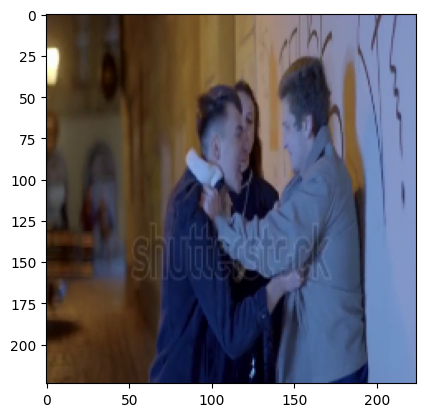

In [561]:
plt.imshow(visible_frame[8])

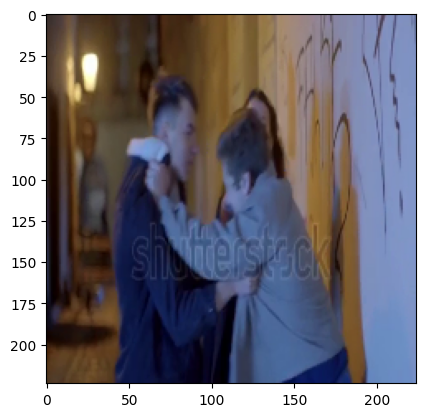

In [562]:
plt.imshow(visible_frame[18])

In [563]:
print(result2[vid_number])
verdict(result3[vid_number])
print(names_custom[vid_number])

[0.98603004 0.01396997]
Fight
fi6768798.mp4
